In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
def load_data(path):
    ext = Path(path).suffix.lower()

    if ext == ".csv":
       return pd.read_csv(path)
    
    elif ext == ".txt":
        return pd.read_csv(path, sep=",")
    else:
         raise ValueError("Неподдерживаемый формат")

In [3]:
df = load_data("../data/raw/nq_rth_30.txt")

In [4]:
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%m/%d/%Y %H:%M:%S"
)
df = df.sort_values("datetime")
print(df.head())

         Date      Time      Open      High       Low     Close    Up  Down  \
0  07/22/2025  15:30:30  23840.25  23843.50  23821.75  23824.25  1422  1499   
1  07/22/2025  15:31:00  23824.50  23824.75  23812.00  23812.00   804   894   
2  07/22/2025  15:31:30  23811.75  23819.50  23794.50  23796.00  1097  1334   
3  07/22/2025  15:32:00  23795.50  23800.50  23787.00  23788.25   918  1019   
4  07/22/2025  15:32:30  23788.00  23788.50  23772.25  23778.00  1148  1333   

   Volume            datetime  
0     0.0 2025-07-22 15:30:30  
1  1698.0 2025-07-22 15:31:00  
2  2431.0 2025-07-22 15:31:30  
3  1937.0 2025-07-22 15:32:00  
4  2481.0 2025-07-22 15:32:30  


In [6]:
df = df[[
    "datetime",
    "Date",
    "Time",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]]
print(df.head())

             datetime        Date      Time      Open      High       Low  \
0 2025-07-22 15:30:30  07/22/2025  15:30:30  23840.25  23843.50  23821.75   
1 2025-07-22 15:31:00  07/22/2025  15:31:00  23824.50  23824.75  23812.00   
2 2025-07-22 15:31:30  07/22/2025  15:31:30  23811.75  23819.50  23794.50   
3 2025-07-22 15:32:00  07/22/2025  15:32:00  23795.50  23800.50  23787.00   
4 2025-07-22 15:32:30  07/22/2025  15:32:30  23788.00  23788.50  23772.25   

      Close  Volume  
0  23824.25     0.0  
1  23812.00  1698.0  
2  23796.00  2431.0  
3  23788.25  1937.0  
4  23778.00  2481.0  


In [7]:
df["date"] = df["datetime"].dt.date
df["time"] = df["datetime"].dt.time

In [12]:
opening = df[
    (df["time"] >= pd.to_datetime("15:30").time())

    &

    (df["time"] <= pd.to_datetime("16:00").time())
]

In [13]:
opening_range = opening.groupby("date").agg(
    OR_high = ("High", "max"),
    OR_low = ("Low", "min"),
    OR_volume = ("Volume", "sum")
)

In [14]:
opening_range["OR_size"] = (
    opening_range["OR_high"] -
    opening_range["OR_low"]
)

In [17]:
print(opening_range.head())

print(df["datetime"].dt.date.nunique())

             OR_high    OR_low  OR_volume  OR_size
date                                              
2025-07-22  23843.50  23606.50    94367.0   237.00
2025-07-23  23757.50  23654.25    63841.0   103.25
2025-07-24  23894.75  23828.00    57485.0    66.75
2025-07-25  23901.75  23824.50    53134.0    77.25
2025-07-28  24015.00  23958.50    53252.0    56.50
126


In [21]:
df["date"].value_counts().describe()

count    126.000000
mean     801.150794
std       56.946159
min      415.000000
25%      810.000000
50%      810.000000
75%      810.000000
max      810.000000
Name: count, dtype: float64

In [24]:
day = df[df["date"] == df["date"].iloc[0]]

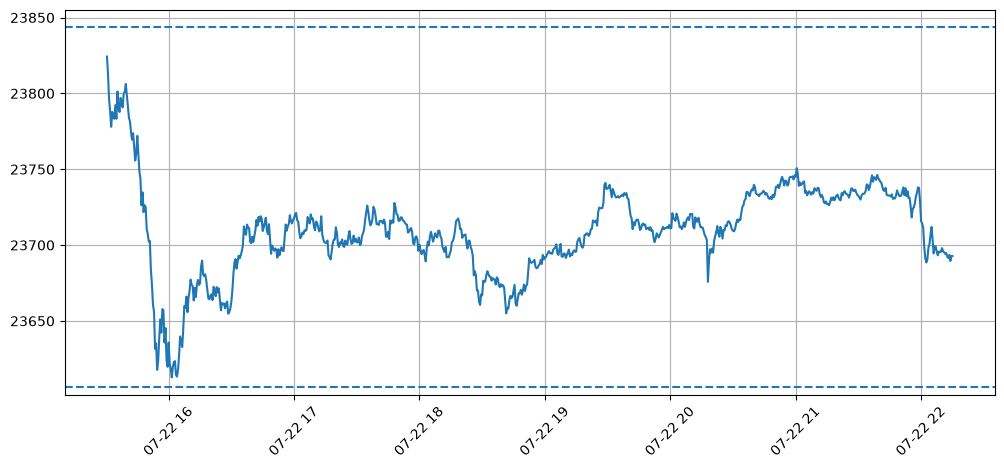

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    day["datetime"],
    day["Close"]
)

plt.axhline(
    opening_range.iloc[0]["OR_high"],
    linestyle="--"
)

plt.axhline(
    opening_range.iloc[0]["OR_low"],
    linestyle="--"
)

plt.xticks(rotation=45)
plt.grid()

plt.show()

In [26]:
df = df.merge(
    opening_range[["OR_high", "OR_low"]],
    on="date",
    how="left"
)

In [27]:
df.head()

,datetime,Date,Time,Open,High,Low,Close,Volume,date,time,OR_high,OR_low
0,2025-07-22 15:30:30,07/22/2025,15:30:30,23840.25,23843.50,23821.75,23824.25,0.0,2025-07-22,15:30:30,23843.5,23606.5
1,2025-07-22 15:31:00,07/22/2025,15:31:00,23824.50,23824.75,23812.00,23812.00,1698.0,2025-07-22,15:31:00,23843.5,23606.5
2,2025-07-22 15:31:30,07/22/2025,15:31:30,23811.75,23819.50,23794.50,23796.00,2431.0,2025-07-22,15:31:30,23843.5,23606.5
3,2025-07-22 15:32:00,07/22/2025,15:32:00,23795.50,23800.50,23787.00,23788.25,1937.0,2025-07-22,15:32:00,23843.5,23606.5
4,2025-07-22 15:32:30,07/22/2025,15:32:30,23788.00,23788.50,23772.25,23778.00,2481.0,2025-07-22,15:32:30,23843.5,23606.5


In [28]:
df["breakout_up"] = df["High"] > df["OR_high"]
df["breakout_down"] = df["Low"] < df["OR_low"]

In [30]:
df["after_opening_range"] = (
    df["time"] >= pd.to_datetime("16:00").time()
)
df["after_opening_range"].value_counts()

after_opening_range
True     93511
False     7434
Name: count, dtype: int64

In [31]:
breakout_down = df[
    (df["after_opening_range"]) &
    (df["Low"] < df["OR_low"])
]
breakout_up = df[
    (df["after_opening_range"]) &
    (df["High"] > df["OR_high"])
]


(32256, 15)

In [ ]:
first_break = (
    df[
        (df["after_opening_range"]) &
        (df["Low"] < df["OR_low"])
    ]
    .groupby("date")
    .first()
)

In [35]:
df["after_opening_range"].value_counts()


after_opening_range
True     93511
False     7434
Name: count, dtype: int64

In [36]:
breakout_down.shape
breakout_up.shape

(32256, 15)